# 09 — Bounded MLP hyperparameter search

This notebook reuses the corrected baseline's exact internal fit/stopping membership, frozen outer random/scaffold splits, Morgan fingerprints, and provisional validation-cliff pairs. Twelve fixed architectures/regularization/learning-rate settings are judged **only by mean internal-stopping MSE** across seeds 42, 7, and 21. The selected setting is then evaluated across all five predeclared seeds after fresh full-training refits.

This is one internal holdout search, not nested cross-validation. Repeated candidate and epoch selection can overfit that holdout; outer validation provides a separate **development-validation** comparison. Earlier project work already inspected outer validation, so final claims remain reserved for untouched test sets after choices are fixed. Outer validation never changes the winning candidate.

**Reference:** All source and supporting files are in [provenance](../provenance/README.md). The data provenance [Excel workbook](../provenance/CB2_data_provenance.xlsx) is the supplied presentation snapshot; reruns preserve it unchanged. Saved outputs below describe the previous execution; printed old paths can differ. Rerun notebooks 00–09 in order to refresh the complete pipeline.

**MLP overview:** Open [summary.xlsx](../provenance/models/multilayer_perceptron/summary.xlsx) for baseline and tuned results and training details, or the adjacent `tuning/` folder for this notebook's original evidence. A successful execution replaces this variant's current result and regenerates the combined workbook.


## 1. Verify preparation and the corrected baseline handoff

The baseline completion manifest, internal assignments, and fixed cliff pairs are explicit dependencies. Check their hashes before any search; this notebook does not regenerate a split or a cliff definition.


In [1]:
from pathlib import Path
import sys
# Shared storage helpers keep the notebooks on the same completed dataset.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
sys.path.insert(0, str(project_root / "scripts"))
from provenance_support import (
    latest_acquisition, current_selection, current_curation, current_preparation,
    current_mlp_baseline, save_review_record, load_review_record,
)
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import json
import platform

import joblib
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import rdkit
import sklearn
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split, GroupShuffleSplit
from rdkit import DataStructs
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

PREP_MANIFEST_REL = current_preparation(project_root)
MLP_NAMES = {"random": "random_mlp", "scaffold": "scaffold_mlp"}
SUBSETS = ("train", "validation", "test")
run_started_at_utc = datetime.now(timezone.utc).isoformat()
# Accept running from the repository root or its notebooks folder.
project_root = Path.cwd().resolve()
if project_root.name == "notebooks":
    project_root = project_root.parent
assert (project_root / "notebooks/03_modeling_preparation.ipynb").is_file()

def sha256_file(path):
    """Read bytes in chunks to verify recorded source and output files."""
    digest = hashlib.sha256()
    with path.open("rb") as stream:
        for chunk in iter(lambda: stream.read(1024 * 1024), b""):
            digest.update(chunk)
    return digest.hexdigest()

# The named run must be complete and must have passed every recorded preparation check.
prep_manifest_path = project_root / PREP_MANIFEST_REL
assert prep_manifest_path.is_file(), f"Preparation manifest is missing: {prep_manifest_path}"
with prep_manifest_path.open(encoding="utf-8") as stream:
    prep_manifest = json.load(stream)
assert prep_manifest.get("completed_at_utc") and prep_manifest.get("stage") == "modeling_preparation"
required_checks = (
    "source_hashes", "saved_arrays_and_fingerprint_bits", "saved_splits_and_scaffolds",
    "saved_audit_reports",
)
for check in required_checks:
    assert prep_manifest.get("verification", {}).get(check) is True, check
assert prep_manifest.get("models_fitted") is False
prep_folder_rel = Path(prep_manifest["output_folder"])
assert (project_root / prep_folder_rel).resolve() == prep_manifest_path.parent.resolve()
# Only the frozen array, split, and similarity files enter this baseline.
required_filenames = (
    "fingerprints_and_targets.npz", "split_assignments.csv", "heldout_training_neighbors.csv",
)
artifact_paths = {}
for filename in required_filenames:
    relative_name = (prep_folder_rel / filename).as_posix()
    assert relative_name in prep_manifest["artifact_sha256"], filename
    artifact_path = project_root / relative_name
    assert artifact_path.is_file(), f"Preparation artifact is missing: {relative_name}"
    assert sha256_file(artifact_path) == prep_manifest["artifact_sha256"][relative_name], relative_name
    artifact_paths[filename] = artifact_path
source_manifest_hash = sha256_file(prep_manifest_path)

# Exact package versions avoid changing fingerprint interpretation or estimator behavior silently.
# The operating system is recorded too: tree libraries can resolve near-tied splits
# differently on Windows and Linux, so results are only exactly comparable on one OS.
installed_versions = {
    "python": platform.python_version(), "platform": platform.system(), "rdkit": rdkit.__version__,
    "numpy": np.__version__, "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__, "joblib": joblib.__version__,
}
# A version mismatch could change fingerprint or estimator behavior between runs.
version_differences = {
    package: (saved, installed_versions.get(package))
    for package, saved in prep_manifest["software_versions"].items()
    if installed_versions.get(package) != saved
}
assert not version_differences, f"Preparation/current software versions differ: {version_differences}"
print(f"{'Preparation run':<27} | {PREP_MANIFEST_REL.as_posix()}")
print(f"{'Verified input artifacts':<27} | {len(artifact_paths):>7,}")
print(f"{'scikit-learn version':<27} | {sklearn.__version__}")
BASELINE_MANIFEST_REL = current_mlp_baseline(project_root)
baseline_manifest_path = project_root / BASELINE_MANIFEST_REL
assert baseline_manifest_path.is_file()
with baseline_manifest_path.open(encoding="utf-8") as stream:
    baseline_manifest = json.load(stream)
assert baseline_manifest["stage"] == "mlp_baseline_training_and_evaluation"
assert baseline_manifest["source_preparation_manifest_sha256"] == source_manifest_hash
assert baseline_manifest["verification"]["training_only_epoch_selection"] is True
assert baseline_manifest["test_predictions_performed"] is False
baseline_manifest_hash = sha256_file(baseline_manifest_path)
# The baseline's fitted models are stored outside git (see README, "Fitted models").
# Confirm they are downloaded and unchanged first, so a fresh clone stops with a
# clear "run scripts/fetch_models.py" instruction instead of a bare missing-file error.
from fetch_models import require_models
require_models(project_root, baseline_manifest_path.parent.relative_to(project_root))
for relative_name, expected_hash in baseline_manifest["output_sha256"].items():
    assert sha256_file(project_root / relative_name) == expected_hash, relative_name
baseline_folder = baseline_manifest_path.parent
print(f"Verified corrected baseline: {BASELINE_MANIFEST_REL.as_posix()}")


Preparation run             | provenance/preparation/manifest.json
Verified input artifacts    |       3
scikit-learn version        | 1.9.0
Verified corrected baseline: provenance/models/multilayer_perceptron/baseline/manifest.json


## 2. Align frozen outer and internal memberships

The array-to-structure mapping and outer split checks match the baseline notebook. Read the baseline's internal assignment and cliff-pair files, then verify they contain only the appropriate outer rows.


In [2]:
# NPZ loading disallows pickled objects and preserves the preparation row order.
with np.load(artifact_paths["fingerprints_and_targets.npz"], allow_pickle=False) as saved:
    X = saved["X"]
    y = saved["y"]
    structure_keys = saved["rdkit_smiles"]
feature_width = int(prep_manifest["configuration"]["fingerprint"]["bits"])
assert X.ndim == 2 and X.shape[1] == feature_width
assert X.dtype == np.uint8 and np.isin(X, (0, 1)).all()
assert y.ndim == 1 and len(X) == len(y) == len(structure_keys)
assert np.isfinite(y).all() and structure_keys.dtype.kind == "U"
assert len(set(structure_keys)) == len(structure_keys) == prep_manifest["counts"]["structures"]

# scikit-learn's network expects floating-point input; this preserves every binary bit.
X_float = X.astype(np.float32)
np.testing.assert_array_equal(X_float, X)

# Map saved labels through structure keys rather than relying on CSV row position.
assignments = pd.read_csv(artifact_paths["split_assignments.csv"], dtype=str, keep_default_na=False)
assert list(assignments.columns) == [
    "split_strategy", "rdkit_smiles", "subset", "scaffold", "fingerprint_group_id"
]
assert len(assignments) == len(structure_keys) * len(MLP_NAMES)
assert not assignments.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert set(assignments["split_strategy"]) == set(MLP_NAMES)
assert set(assignments["subset"]) == set(SUBSETS)
# Translate saved structure labels into array positions without shuffling rows.
split_indices = {}
for strategy in MLP_NAMES:
    rows = assignments.loc[assignments["split_strategy"].eq(strategy)]
    assert set(rows["rdkit_smiles"]) == set(structure_keys)
    subset_by_key = dict(zip(rows["rdkit_smiles"], rows["subset"]))
    labels = np.asarray([subset_by_key[key] for key in structure_keys])
    split_indices[strategy] = {}
    for subset in SUBSETS:
        indices = np.flatnonzero(labels == subset)
        expected = prep_manifest["counts"]["split_subsets"][strategy][subset]["structures"]
        assert len(indices) == expected and len(indices) > 0
        assert set(structure_keys[indices]) == set(rows.loc[rows["subset"].eq(subset), "rdkit_smiles"])
        split_indices[strategy][subset] = indices
# Disjointness protects the held-out labels from entering training updates.
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["validation"])
    assert set(split_indices[strategy]["train"]).isdisjoint(split_indices[strategy]["test"])
    assert set(split_indices[strategy]["validation"]).isdisjoint(split_indices[strategy]["test"])
    print(f"{strategy:<10} | train {len(split_indices[strategy]['train']):>5,} | "
          f"validation {len(split_indices[strategy]['validation']):>4,} | "
          f"reserved test {len(split_indices[strategy]['test']):>4,}")
internal_assignments = pd.read_csv(baseline_folder / "internal_assignments.csv", dtype=str, keep_default_na=False)
cliff_pairs = pd.read_csv(baseline_folder / "cliff_pairs.csv", keep_default_na=False)
assert not internal_assignments.duplicated(["split_strategy", "rdkit_smiles"]).any()
assert not cliff_pairs.duplicated(["split_strategy", "left_rdkit_smiles", "right_rdkit_smiles"]).any()
internal_indices = {}
cliff_participants = {}
for strategy in MLP_NAMES:
    rows = internal_assignments.loc[internal_assignments["split_strategy"].eq(strategy)]
    outer_train = set(structure_keys[split_indices[strategy]["train"]])
    assert set(rows["rdkit_smiles"]) == outer_train
    assert set(rows["split_seed"]) == {"2026"}
    internal_indices[strategy] = {}
    for phase in ("fit", "stopping"):
        keys = set(rows.loc[rows["internal_subset"].eq(phase), "rdkit_smiles"])
        indices = np.asarray([index for index in split_indices[strategy]["train"]
                              if str(structure_keys[index]) in keys], dtype=int)
        assert len(indices) == len(keys) > 0
        internal_indices[strategy][phase] = indices
    assert set(internal_indices[strategy]["fit"]).isdisjoint(internal_indices[strategy]["stopping"])
    if strategy == "scaffold":
        fit_groups = set(rows.loc[rows["internal_subset"].eq("fit"), "scaffold"])
        stop_groups = set(rows.loc[rows["internal_subset"].eq("stopping"), "scaffold"])
        assert fit_groups.isdisjoint(stop_groups)
    pairs = cliff_pairs.loc[cliff_pairs["split_strategy"].eq(strategy)]
    participants = set(pairs["left_rdkit_smiles"]) | set(pairs["right_rdkit_smiles"])
    assert participants <= set(structure_keys[split_indices[strategy]["validation"]])
    cliff_participants[strategy] = participants
    print(f"{strategy:<10} | fit {len(internal_indices[strategy]['fit']):>5,} | "
          f"stopping {len(internal_indices[strategy]['stopping']):>5,} | cliff pairs {len(pairs):>5,}")


random     | train 2,860 | validation  358 | reserved test  358
scaffold   | train 2,778 | validation  461 | reserved test  337
random     | fit 2,288 | stopping   572 | cliff pairs    11
scaffold   | fit 2,169 | stopping   609 | cliff pairs   110


## 3. Declare the fixed grid and training rule

Three hidden-layer choices × two L2 values × two learning rates form 12 candidates. ReLU, linear output, Adam, batch size 64, unscaled binary bits, 250 maximum epochs, and patience 20 remain fixed. The same internal assignments apply to every candidate and seed. A strict new minimum selects an epoch; tied stopping losses keep the earlier epoch.


In [3]:
from itertools import product

# Three seeds score every candidate; five seeds assess the selected setting.
search_seeds = [42, 7, 21]
all_seeds = [42, 7, 21, 84, 2026]
max_epochs = 250
patience = 20
# Declare the complete grid before any outer-validation result is loaded.
candidate_rows = []
for candidate_index, (layers, alpha, learning_rate) in enumerate(product(
    [(16,), (32,), (32, 16)], [0.01, 0.1], [0.0003, 0.001]
)):
    widths = (feature_width, *layers, 1)
    n_parameters = sum((left + 1) * right for left, right in zip(widths[:-1], widths[1:]))
    candidate_rows.append({"candidate_index": candidate_index, "hidden_layers": tuple(layers),
                           "alpha": alpha, "learning_rate_init": learning_rate,
                           "trainable_parameters": n_parameters})
assert len(candidate_rows) == 12
# Only architecture, L2, and learning rate vary across candidates.
def parameters_for_candidate(candidate):
    """Keep every control except the three declared grid values fixed."""
    return {"loss": "squared_error", "hidden_layer_sizes": candidate["hidden_layers"],
            "activation": "relu", "solver": "adam", "alpha": candidate["alpha"],
            "batch_size": 64, "learning_rate_init": candidate["learning_rate_init"],
            "shuffle": True, "early_stopping": False,
            "max_iter": 1, "n_iter_no_change": max_epochs + 1}
print(f"Candidates per protocol: {len(candidate_rows)} | search seeds: {search_seeds} | final seeds: {all_seeds}")

def select_epoch_on_internal_fit(fit_x, fit_y, stop_x, stop_y, parameters, seed):
    """Train one initialization without ever receiving outer-validation arrays."""
    model = MLPRegressor(**parameters, random_state=seed)
    best_mse, best_epoch, stale = np.inf, 0, 0
    rows = []
    for epoch in range(1, max_epochs + 1):
        model.partial_fit(fit_x, fit_y)
        fit_mse = float(np.mean((model.predict(fit_x) - fit_y) ** 2))
        stop_mse = float(np.mean((model.predict(stop_x) - stop_y) ** 2))
        assert np.isfinite(fit_mse) and np.isfinite(stop_mse)
        rows.append({"epoch": epoch, "fit_mse_pki2": fit_mse, "stopping_mse_pki2": stop_mse})
        # A strict minimum and first-tie rule make the selected duration deterministic.
        if stop_mse < best_mse:
            best_mse, best_epoch, stale = stop_mse, epoch, 0
        else:
            stale += 1
        if stale >= patience:
            break
    reason = "patience" if stale >= patience else "max_epochs"
    return best_epoch, best_mse, reason, rows

def fresh_full_refit(train_x, train_y, parameters, seed, selected_epochs):
    """Initialize anew and fit on all outer-training rows for the selected duration."""
    model = MLPRegressor(**parameters, random_state=seed)
    rows = []
    for epoch in range(1, selected_epochs + 1):
        model.partial_fit(train_x, train_y)
        rows.append({"epoch": epoch, "training_mse_pki2": float(np.mean(
            (model.predict(train_x) - train_y) ** 2))})
    assert len(rows) == selected_epochs
    return model, rows

def metric_record(observed, predicted):
    """Return the same MAE, RMSE, and R² definitions as prior model notebooks."""
    errors = predicted - observed
    defined = len(observed) >= 2 and np.max(observed) > np.min(observed)
    return {"n_structures": len(observed), "mae_pki": float(np.mean(np.abs(errors))),
            "rmse_pki": float(np.sqrt(np.mean(errors ** 2))),
            "r2": float(r2_score(observed, predicted)) if defined else np.nan,
            "r2_status": "defined" if defined else (
                "undefined_empty" if not len(observed) else "undefined_small_or_constant_target")}


Candidates per protocol: 12 | search seeds: [42, 7, 21] | final seeds: [42, 7, 21, 84, 2026]


## 4. Score all candidates on internal stopping rows

Each candidate receives one independently initialized internal fit for each search seed. The selection score is the arithmetic mean of their best stopping MSE. Ties resolve by fewer trainable parameters, then stronger L2, then lower learning rate, then declared candidate order. No outer-validation prediction is made in this section.


In [4]:
# Save every candidate and epoch so the winning score can be audited.
candidate_score_rows, candidate_history_rows = [], []
for strategy in MLP_NAMES:
    fit_indices = internal_indices[strategy]["fit"]
    stop_indices = internal_indices[strategy]["stopping"]
    for candidate in candidate_rows:
        parameters = parameters_for_candidate(candidate)
        for seed in search_seeds:
            started = perf_counter()
            # Candidate fitting receives only this protocol’s internal arrays.
            epoch, stopping_mse, reason, history = select_epoch_on_internal_fit(
                X_float[fit_indices], y[fit_indices], X_float[stop_indices], y[stop_indices],
                parameters, seed,
            )
            candidate_score_rows.append({
                "split_strategy": strategy, "candidate_index": candidate["candidate_index"],
                "hidden_layers_json": json.dumps(candidate["hidden_layers"]),
                "alpha": candidate["alpha"], "learning_rate_init": candidate["learning_rate_init"],
                "trainable_parameters": candidate["trainable_parameters"],
                "initialization_seed": seed, "best_stopping_mse_pki2": stopping_mse,
                "selected_epoch": epoch, "internal_epochs_run": len(history),
                "stopping_reason": reason, "fit_seconds": perf_counter() - started,
            })
            for row in history:
                candidate_history_rows.append({"split_strategy": strategy,
                                               "candidate_index": candidate["candidate_index"],
                                               "initialization_seed": seed, **row})
    print(f"Finished {strategy} candidate fits: {len(candidate_rows) * len(search_seeds)}")
candidate_scores = pd.DataFrame(candidate_score_rows)
candidate_history = pd.DataFrame(candidate_history_rows)
# Candidate selection uses mean best stopping MSE over three fixed seeds.
summary_rows = []
selection = {}
for strategy in MLP_NAMES:
    rows = candidate_scores.loc[candidate_scores["split_strategy"].eq(strategy)]
    for candidate in candidate_rows:
        scores = rows.loc[rows["candidate_index"].eq(candidate["candidate_index"])]
        assert set(scores["initialization_seed"]) == set(search_seeds)
        summary_rows.append({"split_strategy": strategy, **candidate,
                             "mean_best_stopping_mse_pki2": float(scores["best_stopping_mse_pki2"].mean()),
                             "sample_sd_best_stopping_mse_pki2": float(scores["best_stopping_mse_pki2"].std(ddof=1))})
candidate_summary = pd.DataFrame(summary_rows)
for strategy in MLP_NAMES:
    # Sort by score, then the predeclared deterministic tie-break fields.
    ranked = candidate_summary.loc[candidate_summary["split_strategy"].eq(strategy)].sort_values(
        ["mean_best_stopping_mse_pki2", "trainable_parameters", "alpha",
         "learning_rate_init", "candidate_index"],
        ascending=[True, True, False, True, True], kind="mergesort",
    )
    winner = ranked.iloc[0]
    selection[strategy] = {
        "candidate_index": int(winner["candidate_index"]),
        "hidden_layers": list(winner["hidden_layers"]),
        "alpha": float(winner["alpha"]),
        "learning_rate_init": float(winner["learning_rate_init"]),
        "trainable_parameters": int(winner["trainable_parameters"]),
        "mean_best_stopping_mse_pki2": float(winner["mean_best_stopping_mse_pki2"]),
    }
    print(f"{strategy:<10} | candidate {winner['candidate_index']:>2,} | "
          f"mean internal MSE {winner['mean_best_stopping_mse_pki2']:.4f} | "
          f"layers {winner['hidden_layers']} | alpha {winner['alpha']} | LR {winner['learning_rate_init']}")
# Mark exactly one candidate per protocol before outer validation is evaluated.
candidate_summary["selected"] = candidate_summary.apply(
    lambda row: row["candidate_index"] == selection[row["split_strategy"]]["candidate_index"], axis=1
)


Finished random candidate fits: 36


Finished scaffold candidate fits: 36
random     | candidate 10 | mean internal MSE 0.7877 | layers (32, 16) | alpha 0.1 | LR 0.0003
scaffold   | candidate 11 | mean internal MSE 1.0265 | layers (32, 16) | alpha 0.1 | LR 0.001


## 5. Select epochs for all five seeds and refit on complete outer training

The three search-seed internal histories are reused for the winner. Seeds 84 and 2026 receive new internal fits with that same selected configuration. Every final model starts fresh and trains on the complete outer-training set for its internally selected number of epochs. Only then are outer training and validation predictions made.


In [5]:
# Search-seed histories can be reused without training those internal fits twice.
models = {}
selected_history_rows, selection_rows, refit_history_rows = [], [], []
prediction_rows, metric_rows = [], []
for strategy in MLP_NAMES:
    chosen = candidate_rows[selection[strategy]["candidate_index"]]
    parameters = parameters_for_candidate(chosen)
    fit_indices = internal_indices[strategy]["fit"]
    stop_indices = internal_indices[strategy]["stopping"]
    train_indices = split_indices[strategy]["train"]
    models[strategy] = {}
    for seed in all_seeds:
        started = perf_counter()
        # The two additional seeds receive new internal fits with the chosen settings.
        if seed in search_seeds:
            score = candidate_scores.loc[candidate_scores["split_strategy"].eq(strategy)
                                         & candidate_scores["candidate_index"].eq(chosen["candidate_index"])
                                         & candidate_scores["initialization_seed"].eq(seed)].iloc[0]
            epoch = int(score["selected_epoch"])
            stopping_mse = float(score["best_stopping_mse_pki2"])
            reason = score["stopping_reason"]
            history = candidate_history.loc[candidate_history["split_strategy"].eq(strategy)
                                            & candidate_history["candidate_index"].eq(chosen["candidate_index"])
                                            & candidate_history["initialization_seed"].eq(seed)]
            history_records = history[["epoch", "fit_mse_pki2", "stopping_mse_pki2"]].to_dict("records")
            source = "reused_candidate_fit"
        else:
            epoch, stopping_mse, reason, history_records = select_epoch_on_internal_fit(
                X_float[fit_indices], y[fit_indices], X_float[stop_indices], y[stop_indices],
                parameters, seed,
            )
            source = "new_selected_configuration_fit"
        for row in history_records:
            selected_history_rows.append({"split_strategy": strategy, "model_variant": "tuned",
                                          "initialization_seed": seed, "training_phase": "internal_selection", **row})
        # A newly initialized model sees all outer-training molecules for the selected duration.
        final_model, history = fresh_full_refit(
            X_float[train_indices], y[train_indices], parameters, seed, epoch
        )
        models[strategy][seed] = final_model
        for row in history:
            refit_history_rows.append({"split_strategy": strategy, "model_variant": "tuned",
                                       "initialization_seed": seed, "training_phase": "final_full_refit",
                                       "training_structures": len(train_indices), **row})
        selection_rows.append({
            "split_strategy": strategy, "model_variant": "tuned", "initialization_seed": seed,
            "candidate_index": chosen["candidate_index"], "internal_split_seed": 2026,
            "selected_epoch": epoch, "best_stopping_mse_pki2": stopping_mse,
            "internal_epochs_run": len(history_records), "stopping_reason": reason,
            "internal_history_source": source, "full_refit_epochs_run": len(history),
            "full_refit_structures": len(train_indices), "trainable_parameters": chosen["trainable_parameters"],
            "additional_seconds": perf_counter() - started,
        })
        # Validation is predicted after all selection and refit decisions.
        for subset in ("train", "validation"):
            indices = split_indices[strategy][subset]
            observed, predicted = y[indices], final_model.predict(X_float[indices])
            assert np.isfinite(predicted).all()
            for key, actual, estimate in zip(structure_keys[indices], observed, predicted):
                residual = float(estimate - actual)
                prediction_rows.append({"split_strategy": strategy, "model_variant": "tuned",
                                        "initialization_seed": seed, "training_phase": "final_full_refit",
                                        "subset": subset, "rdkit_smiles": str(key),
                                        "observed_pki": float(actual), "predicted_pki": float(estimate),
                                        "residual": residual, "absolute_error": abs(residual),
                                        "squared_error": residual ** 2})
            metric_rows.append({"split_strategy": strategy, "model_variant": "tuned",
                                "initialization_seed": seed, "training_phase": "final_full_refit",
                                "subset": subset, **metric_record(observed, predicted)})
        print(f"{strategy:<10} | seed {seed:>4,} | epoch {epoch:>3,} | internal MSE {stopping_mse:.4f}")
selected_history = pd.DataFrame(selected_history_rows)
selections = pd.DataFrame(selection_rows)
refit_history = pd.DataFrame(refit_history_rows)
predictions = pd.DataFrame(prediction_rows)
metrics = pd.DataFrame(metric_rows)
assert not predictions.duplicated(["split_strategy", "initialization_seed", "subset", "rdkit_smiles"]).any()


random     | seed   42 | epoch  55 | internal MSE 0.7811


random     | seed    7 | epoch  52 | internal MSE 0.7920


random     | seed   21 | epoch  59 | internal MSE 0.7902


random     | seed   84 | epoch  62 | internal MSE 0.8100


random     | seed 2,026 | epoch  39 | internal MSE 0.8611


scaffold   | seed   42 | epoch  15 | internal MSE 1.0105


scaffold   | seed    7 | epoch  10 | internal MSE 1.0270


scaffold   | seed   21 | epoch  16 | internal MSE 1.0421


scaffold   | seed   84 | epoch  14 | internal MSE 0.9833


scaffold   | seed 2,026 | epoch  11 | internal MSE 1.0458


## 6. Compare baseline and tuned models by seed

The baseline metrics are read from the completed corrected baseline run after selection. Compare matching seeds and frozen molecules, then report the arithmetic mean and sample standard deviation of seed-level metrics. A negative tuned-minus-baseline MAE is an improvement; the winner is never changed using outer validation.


In [6]:
# Load baseline outer metrics only after the candidate winner is fixed.
baseline_metrics = pd.read_csv(baseline_folder / "metrics.csv")
assert set(baseline_metrics["initialization_seed"]) == set(all_seeds)
# Compare the same seed and the same frozen molecules under both variants.
comparison = pd.concat([baseline_metrics, metrics], ignore_index=True)
assert not comparison.duplicated(["split_strategy", "model_variant", "initialization_seed", "subset"]).any()
summary_rows = []
for strategy in MLP_NAMES:
    for variant in ("baseline", "tuned"):
        for subset in ("train", "validation"):
            rows = comparison.loc[comparison["split_strategy"].eq(strategy)
                                  & comparison["model_variant"].eq(variant)
                                  & comparison["subset"].eq(subset)]
            assert set(rows["initialization_seed"]) == set(all_seeds)
            result = {"split_strategy": strategy, "model_variant": variant, "subset": subset,
                      "n_seeds": len(rows), "n_structures_per_seed": int(rows.iloc[0]["n_structures"])}
            # Sample SD summarizes model-level seed variability on one split.
            for field in ("mae_pki", "rmse_pki", "r2"):
                result[f"{field}_mean"] = float(rows[field].mean())
                result[f"{field}_sample_sd"] = float(rows[field].std(ddof=1))
            summary_rows.append(result)
seed_summary = pd.DataFrame(summary_rows)
print(f"{'Protocol':<10} | {'Seed':>5} | {'Subset':<10} | {'Baseline MAE':>12} | {'Tuned MAE':>10} | {'Change':>8}")
# A positive tuned-minus-baseline MAE means the tuned seed did worse.
for strategy in MLP_NAMES:
    for seed in all_seeds:
        for subset in ("train", "validation"):
            rows = comparison.loc[comparison["split_strategy"].eq(strategy)
                                  & comparison["initialization_seed"].eq(seed)
                                  & comparison["subset"].eq(subset)]
            assert set(rows["model_variant"]) == {"baseline", "tuned"}
            base = rows.loc[rows["model_variant"].eq("baseline"), "mae_pki"].iloc[0]
            tuned = rows.loc[rows["model_variant"].eq("tuned"), "mae_pki"].iloc[0]
            print(f"{strategy:<10} | {seed:>5,} | {subset:<10} | {base:>12.3f} | {tuned:>10.3f} | {tuned-base:>+8.3f}")
print("Mean ± sample SD by model-level metrics:")
for row in seed_summary.itertuples(index=False):
    print(f"{row.split_strategy:<10} | {row.model_variant:<8} | {row.subset:<10} | "
          f"MAE {row.mae_pki_mean:.3f}±{row.mae_pki_sample_sd:.3f} | "
          f"RMSE {row.rmse_pki_mean:.3f}±{row.rmse_pki_sample_sd:.3f} | "
          f"R² {row.r2_mean:.3f}±{row.r2_sample_sd:.3f}")


Protocol   |  Seed | Subset     | Baseline MAE |  Tuned MAE |   Change
random     |    42 | train      |        0.421 |      0.247 |   -0.174
random     |    42 | validation |        0.634 |      0.586 |   -0.048
random     |     7 | train      |        0.380 |      0.317 |   -0.063
random     |     7 | validation |        0.640 |      0.612 |   -0.028
random     |    21 | train      |        0.400 |      0.301 |   -0.099
random     |    21 | validation |        0.615 |      0.591 |   -0.025
random     |    84 | train      |        0.386 |      0.288 |   -0.098
random     |    84 | validation |        0.620 |      0.607 |   -0.014
random     | 2,026 | train      |        0.363 |      0.425 |   +0.062
random     | 2,026 | validation |        0.646 |      0.638 |   -0.008
scaffold   |    42 | train      |        0.439 |      0.433 |   -0.007
scaffold   |    42 | validation |        0.729 |      0.730 |   +0.001
scaffold   |     7 | train      |        0.485 |      0.474 |   -0.011
scaffo

## 7. Repeat similarity and exploratory cliff diagnostics

Reuse the exact similarity audit and baseline cliff-pair table. These are evaluation subgroups, not inputs to candidate or epoch selection. Each seed receives separate reports; summaries average model-level metrics without treating repeated molecules or overlapping pairs as independent.


In [7]:
# The baseline’s frozen nearest-training audit supplies similarity categories.
neighbors = pd.read_csv(artifact_paths["heldout_training_neighbors.csv"], dtype=str, keep_default_na=False)
validation_neighbors = neighbors.loc[neighbors["subset"].eq("validation")].copy()
assert not validation_neighbors.duplicated(["split_strategy", "subset", "rdkit_smiles"]).any()
assert set(validation_neighbors["exact_training_fingerprint_match"]) <= {"True", "False"}
validation_neighbors["exact_training_fingerprint_match"] = validation_neighbors[
    "exact_training_fingerprint_match"].map({"True": True, "False": False}).astype(bool)
validation_neighbors["maximum_tanimoto"] = pd.to_numeric(validation_neighbors["maximum_tanimoto"])
cutoff = prep_manifest["configuration"]["diagnostics"]["high_tanimoto_at_least"]
assert cutoff == 0.80 and validation_neighbors["maximum_tanimoto"].between(0, 1).all()
assert (validation_neighbors["exact_training_fingerprint_match"] ==
        validation_neighbors["maximum_tanimoto"].eq(1.0)).all()
# Five seed predictions reuse one neighbor record per molecule.
joined_validation = predictions.loc[predictions["subset"].eq("validation")].merge(
    validation_neighbors[["split_strategy", "subset", "rdkit_smiles", "maximum_tanimoto",
                          "exact_training_fingerprint_match", "nearest_training_rdkit_smiles"]],
    on=["split_strategy", "subset", "rdkit_smiles"], how="left", validate="many_to_one", indicator=True,
)
assert joined_validation["_merge"].eq("both").all()
joined_validation = joined_validation.drop(columns="_merge")
subgroup_rows = []
for strategy in MLP_NAMES:
    for seed in all_seeds:
        rows = joined_validation.loc[joined_validation["split_strategy"].eq(strategy)
                                     & joined_validation["initialization_seed"].eq(seed)]
        # Group definitions stay identical to the corrected baseline.
        partitions = [
            ("exact_training_fingerprint", "exact_match", rows["exact_training_fingerprint_match"]),
            ("exact_training_fingerprint", "no_exact_match", ~rows["exact_training_fingerprint_match"]),
            ("nearest_training_tanimoto_0.80", "below_0.80", rows["maximum_tanimoto"].lt(cutoff)),
            ("nearest_training_tanimoto_0.80", "at_least_0.80", rows["maximum_tanimoto"].ge(cutoff)),
        ]
        for grouping, group, mask in partitions:
            selected = rows.loc[mask]
            if len(selected):
                subgroup_metric = metric_record(selected["observed_pki"].to_numpy(),
                                                selected["predicted_pki"].to_numpy())
            else:
                subgroup_metric = {"n_structures": 0, "mae_pki": np.nan, "rmse_pki": np.nan,
                                   "r2": np.nan, "r2_status": "undefined_empty"}
            subgroup_rows.append({"split_strategy": strategy, "model_variant": "tuned",
                                  "initialization_seed": seed, "grouping": grouping, "group": group,
                                  **subgroup_metric})
subgroups = pd.DataFrame(subgroup_rows)
subgroup_summary = subgroups.groupby(["split_strategy", "model_variant", "grouping", "group"],
                                     as_index=False).agg(
    n_structures=("n_structures", "first"), n_seeds=("initialization_seed", "size"),
    mae_pki_mean=("mae_pki", "mean"), mae_pki_sample_sd=("mae_pki", "std"),
    rmse_pki_mean=("rmse_pki", "mean"), rmse_pki_sample_sd=("rmse_pki", "std"),
)
print(f"{'Protocol':<10} | {'Grouping':<31} | {'Category':<15} | {'N':>5} | {'Mean MAE':>8} | {'SD':>7}")
for row in subgroup_summary.itertuples(index=False):
    mae = f"{row.mae_pki_mean:.3f}" if row.n_structures else "undefined"
    sd = f"{row.mae_pki_sample_sd:.3f}" if row.n_structures else "undefined"
    print(f"{row.split_strategy:<10} | {row.grouping:<31} | {row.group:<15} | "
          f"{row.n_structures:>5,} | {mae:>8} | {sd:>7}")

# Frozen cliff pairs are evaluation data, never a tuning signal.
cliff_group_rows, cliff_result_rows = [], []
for strategy in MLP_NAMES:
    protocol_pairs = cliff_pairs.loc[cliff_pairs["split_strategy"].eq(strategy)]
    participants = cliff_participants[strategy]
    for seed in all_seeds:
        rows = predictions.loc[predictions["split_strategy"].eq(strategy)
                                & predictions["initialization_seed"].eq(seed)
                                & predictions["subset"].eq("validation")]
        by_key = rows.set_index("rdkit_smiles")
        assert set(participants) <= set(by_key.index)
        for group, mask in (("cliff_participant", rows["rdkit_smiles"].isin(participants)),
                            ("other_validation", ~rows["rdkit_smiles"].isin(participants))):
            selected = rows.loc[mask]
            group_metric = metric_record(selected["observed_pki"].to_numpy(),
                                         selected["predicted_pki"].to_numpy()) if len(selected) else {
                "n_structures": 0, "mae_pki": np.nan, "rmse_pki": np.nan,
                "r2": np.nan, "r2_status": "undefined_empty"}
            cliff_group_rows.append({"split_strategy": strategy, "model_variant": "tuned",
                                     "initialization_seed": seed, "group": group, **group_metric})
        if len(protocol_pairs):
            left = by_key.loc[protocol_pairs["left_rdkit_smiles"], "predicted_pki"].to_numpy()
            right = by_key.loc[protocol_pairs["right_rdkit_smiles"], "predicted_pki"].to_numpy()
            # Pair difference and direction use stable ordered endpoints.
            predicted_difference = left - right
            observed_difference = protocol_pairs["observed_difference_pki"].to_numpy()
            difference_mae = float(np.mean(np.abs(predicted_difference - observed_difference)))
            ties = int(np.count_nonzero(predicted_difference == 0))
            correct = int(np.count_nonzero(np.sign(predicted_difference) == np.sign(observed_difference)))
            direction_fraction = correct / len(protocol_pairs)
        else:
            difference_mae, direction_fraction, ties = np.nan, np.nan, 0
        cliff_result_rows.append({
            "split_strategy": strategy, "model_variant": "tuned", "initialization_seed": seed,
            "n_pairs": len(protocol_pairs), "n_participating_structures": len(participants),
            "pair_difference_mae_pki": difference_mae,
            "correct_direction_fraction": direction_fraction, "predicted_ties": ties,
            "status": "defined" if len(protocol_pairs) else "undefined_no_pairs",
        })
cliff_groups = pd.DataFrame(cliff_group_rows)
cliff_results = pd.DataFrame(cliff_result_rows)
# Report seed-level means rather than counting repeated pairs as independent.
cliff_group_summary = cliff_groups.groupby(["split_strategy", "model_variant", "group"], as_index=False).agg(
    n_structures=("n_structures", "first"), n_seeds=("initialization_seed", "size"),
    mae_pki_mean=("mae_pki", "mean"), mae_pki_sample_sd=("mae_pki", "std"),
    rmse_pki_mean=("rmse_pki", "mean"), rmse_pki_sample_sd=("rmse_pki", "std"),
)
cliff_summary = cliff_results.groupby(["split_strategy", "model_variant"], as_index=False).agg(
    n_pairs=("n_pairs", "first"), n_participating_structures=("n_participating_structures", "first"),
    pair_difference_mae_pki_mean=("pair_difference_mae_pki", "mean"),
    pair_difference_mae_pki_sample_sd=("pair_difference_mae_pki", "std"),
    correct_direction_fraction_mean=("correct_direction_fraction", "mean"),
    correct_direction_fraction_sample_sd=("correct_direction_fraction", "std"),
)
print(f"{'Protocol':<10} | {'Pairs':>6} | {'Molecules':>9} | {'Pair MAE mean±SD':>18} | {'Direction mean±SD':>18}")
for row in cliff_summary.itertuples(index=False):
    pair_text = f"{row.pair_difference_mae_pki_mean:.3f}±{row.pair_difference_mae_pki_sample_sd:.3f}" if row.n_pairs else "undefined"
    direction_text = f"{row.correct_direction_fraction_mean:.3f}±{row.correct_direction_fraction_sample_sd:.3f}" if row.n_pairs else "undefined"
    print(f"{row.split_strategy:<10} | {row.n_pairs:>6,} | {row.n_participating_structures:>9,} | "
          f"{pair_text:>18} | {direction_text:>18}")
print(f"{'Protocol':<10} | {'Validation group':<20} | {'Molecules':>9} | {'MAE mean±SD':>15} | {'RMSE mean±SD':>16}")
for row in cliff_group_summary.itertuples(index=False):
    mae = f"{row.mae_pki_mean:.3f}±{row.mae_pki_sample_sd:.3f}" if row.n_structures else "undefined"
    rmse = f"{row.rmse_pki_mean:.3f}±{row.rmse_pki_sample_sd:.3f}" if row.n_structures else "undefined"
    print(f"{row.split_strategy:<10} | {row.group:<20} | {row.n_structures:>9,} | {mae:>15} | {rmse:>16}")


Protocol   | Grouping                        | Category        |     N | Mean MAE |      SD
random     | exact_training_fingerprint      | exact_match     |    27 |    0.393 |   0.028
random     | exact_training_fingerprint      | no_exact_match  |   331 |    0.624 |   0.020
random     | nearest_training_tanimoto_0.80  | at_least_0.80   |   179 |    0.543 |   0.028
random     | nearest_training_tanimoto_0.80  | below_0.80      |   179 |    0.670 |   0.016
scaffold   | exact_training_fingerprint      | exact_match     |    18 |    0.622 |   0.031
scaffold   | exact_training_fingerprint      | no_exact_match  |   443 |    0.730 |   0.023
scaffold   | nearest_training_tanimoto_0.80  | at_least_0.80   |    86 |    0.668 |   0.025
scaffold   | nearest_training_tanimoto_0.80  | below_0.80      |   375 |    0.739 |   0.025
Protocol   |  Pairs | Molecules |   Pair MAE mean±SD |  Direction mean±SD
random     |     11 |        19 |        1.167±0.052 |        0.891±0.119
scaffold   |    110 |   

## 8. Save plots for the selected configuration

All five selected internal histories show stopping behavior. Seed 42 is the same predeclared representative used by the baseline notebook for predicted-versus-observed, residual, and similarity-error plots.


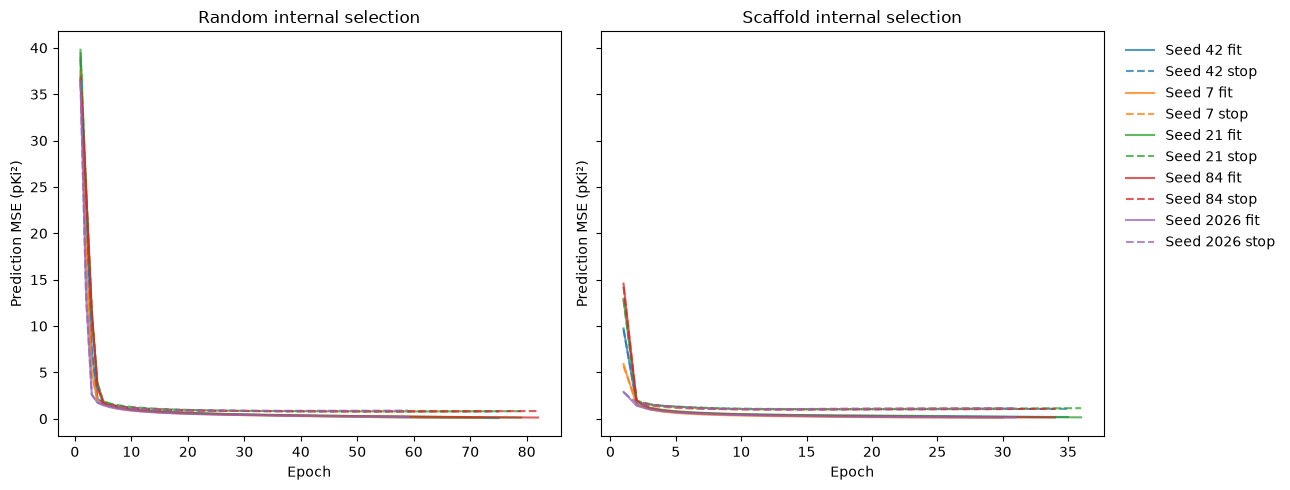

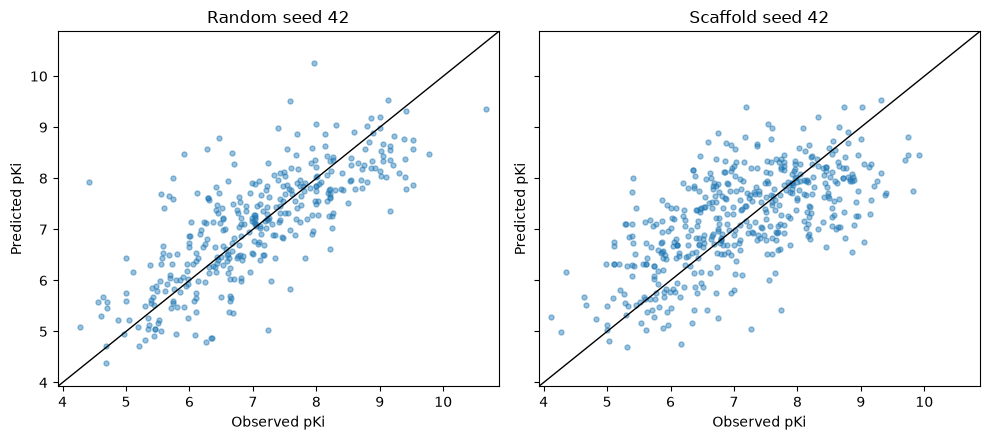

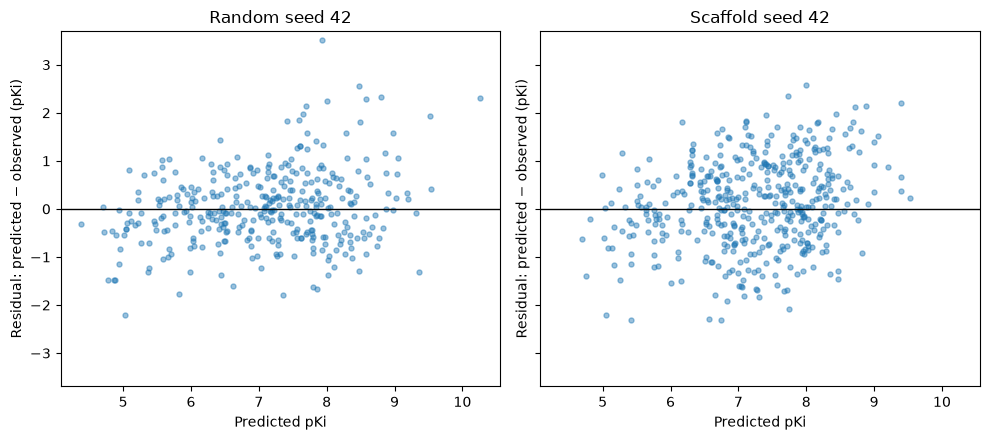

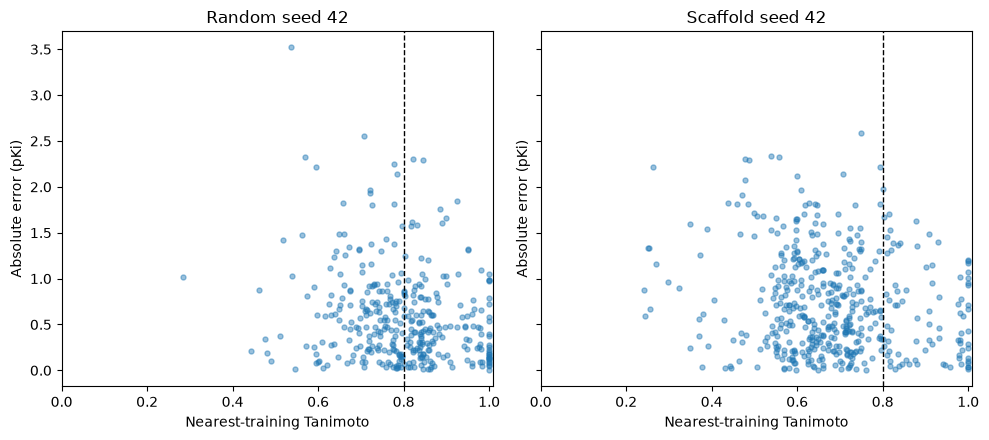

In [8]:
# Save separately until all scientific checks pass, keeping the current result safe.
from mlp_artifacts import new_mlp_candidate, publish_mlp
tuning_folder = new_mlp_candidate(project_root, "tuning")
# Every exported plot is included in the completion hashes.
plot_paths = []

# Each color is one seed; solid is internal fit and dashed is stopping loss.
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    for seed in all_seeds:
        rows = selected_history.loc[selected_history["split_strategy"].eq(strategy)
                                    & selected_history["initialization_seed"].eq(seed)]
        line, = axis.plot(rows["epoch"], rows["fit_mse_pki2"], alpha=0.75, label=f"Seed {seed} fit")
        axis.plot(rows["epoch"], rows["stopping_mse_pki2"], linestyle="--", alpha=0.75,
                  color=line.get_color(), label=f"Seed {seed} stop")
    axis.set(title=f"{strategy.capitalize()} internal selection", xlabel="Epoch", ylabel="Prediction MSE (pKi²)")
axes[1].legend(frameon=False, bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
fig.tight_layout()
path = tuning_folder / "selected_internal_loss_by_seed.png"
fig.savefig(path, dpi=140, bbox_inches="tight")
plot_paths.append(path)
plt.show()

# Seed 42 remains the predeclared visual representative.
representative = joined_validation.loc[joined_validation["initialization_seed"].eq(42)]
lower = float(min(representative["observed_pki"].min(), representative["predicted_pki"].min()) - 0.2)
upper = float(max(representative["observed_pki"].max(), representative["predicted_pki"].max()) + 0.2)
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    rows = representative.loc[representative["split_strategy"].eq(strategy)]
    axis.scatter(rows["observed_pki"], rows["predicted_pki"], s=13, alpha=0.45)
    axis.plot([lower, upper], [lower, upper], color="black", linewidth=1)
    axis.set(xlim=(lower, upper), ylim=(lower, upper), title=f"{strategy.capitalize()} seed 42",
             xlabel="Observed pKi", ylabel="Predicted pKi")
fig.tight_layout()
path = tuning_folder / "observed_vs_predicted_seed_42.png"
fig.savefig(path, dpi=140)
plot_paths.append(path)
plt.show()

# Signed residuals show direction and spread of prediction errors.
limit = 1.05 * float(representative["residual"].abs().max())
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    rows = representative.loc[representative["split_strategy"].eq(strategy)]
    axis.scatter(rows["predicted_pki"], rows["residual"], s=13, alpha=0.45)
    axis.axhline(0, color="black", linewidth=1)
    axis.set(ylim=(-limit, limit), title=f"{strategy.capitalize()} seed 42",
             xlabel="Predicted pKi", ylabel="Residual: predicted − observed (pKi)")
fig.tight_layout()
path = tuning_folder / "residuals_seed_42.png"
fig.savefig(path, dpi=140)
plot_paths.append(path)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 4.5), sharex=True, sharey=True)
for axis, strategy in zip(axes, MLP_NAMES):
    rows = representative.loc[representative["split_strategy"].eq(strategy)]
    axis.scatter(rows["maximum_tanimoto"], rows["absolute_error"], s=13, alpha=0.45)
    axis.axvline(cutoff, color="black", linestyle="--", linewidth=1)
    axis.set(xlim=(0, 1.01), title=f"{strategy.capitalize()} seed 42",
             xlabel="Nearest-training Tanimoto", ylabel="Absolute error (pKi)")
fig.tight_layout()
path = tuning_folder / "similarity_error_seed_42.png"
fig.savefig(path, dpi=140)
plot_paths.append(path)
plt.show()


## 9. Save candidate evidence and final-model reports

The tuning manifest links to the baseline completion manifest and hashes its reused internal assignments and cliff pairs. Candidate scores and selected settings are separate from outer-validation comparisons.


In [9]:
# Candidate evidence and final-model reports are separate artifacts.
report_tables = {
    "candidate_scores.csv": candidate_scores,
    "candidate_history.csv": candidate_history,
    "candidate_summary.csv": candidate_summary,
    "selected_internal_history.csv": selected_history,
    "epoch_selections.csv": selections,
    "full_refit_history.csv": refit_history,
    "predictions.csv": predictions,
    "metrics.csv": metrics,
    "baseline_comparison.csv": comparison,
    "seed_summary.csv": seed_summary,
    "validation_subgroups.csv": subgroups,
    "subgroup_summary.csv": subgroup_summary,
    "cliff_molecule_groups.csv": cliff_groups,
    "cliff_molecule_group_summary.csv": cliff_group_summary,
    "cliff_results.csv": cliff_results,
    "cliff_summary.csv": cliff_summary,
}
# Write all reports before independently reloading them.
for filename, table in report_tables.items():
    table.to_csv(tuning_folder / filename, index=False)
models_path = tuning_folder / "models.joblib.gz"
joblib.dump(models, models_path, compress=("gzip", 3))
# Persist the fixed grid and tie rule alongside the chosen candidate.
with (tuning_folder / "selection.json").open("x", encoding="utf-8") as stream:
    json.dump({"selection": selection,
               "rule": "lowest mean best internal-stopping MSE over seeds 42, 7, 21; "
                       "ties: fewer parameters, stronger L2, lower learning rate, candidate order",
               "grid": [{**row, "hidden_layers": list(row["hidden_layers"])} for row in candidate_rows]},
              stream, indent=2)
# Completion is recorded only after the verification cell succeeds.
print(f"Saved {len(report_tables)} CSV reports, ten tuned models, selection, and {len(plot_paths)} plots.")


Saved 16 CSV reports, ten tuned models, selection, and 4 plots.


## 10. Verify saved selection, refits, metrics, and provenance

Recompute candidate means and winner order from saved internal scores, validate every selected epoch and explicit full-refit history, reload models to reproduce keyed predictions, recalculate subgroup/cliff arithmetic, and check test exclusion and hashes. Write completion only after these checks pass.


In [10]:
# Verify saved files, rather than trusting only live notebook variables.
readback = {name: pd.read_csv(tuning_folder / name, keep_default_na=False)
            for name in report_tables}
loaded_models = joblib.load(models_path)
with (tuning_folder / "selection.json").open(encoding="utf-8") as stream:
    saved_selection = json.load(stream)
assert saved_selection["selection"] == selection
assert set(loaded_models) == set(MLP_NAMES)
saved_scores = readback["candidate_scores.csv"]
saved_candidates = readback["candidate_summary.csv"]
saved_predictions = readback["predictions.csv"]
saved_metrics = readback["metrics.csv"]
saved_selections = readback["epoch_selections.csv"]
saved_history = readback["selected_internal_history.csv"]
saved_refit = readback["full_refit_history.csv"]
# Rebuild candidate means and the winner from internal scores alone.
for strategy in MLP_NAMES:
    rows = saved_scores.loc[saved_scores["split_strategy"].eq(strategy)]
    assert len(rows) == len(candidate_rows) * len(search_seeds)
    for candidate in candidate_rows:
        group = rows.loc[rows["candidate_index"].eq(candidate["candidate_index"])]
        assert set(group["initialization_seed"]) == set(search_seeds)
        summary = saved_candidates.loc[saved_candidates["split_strategy"].eq(strategy)
                                       & saved_candidates["candidate_index"].eq(candidate["candidate_index"])].iloc[0]
        assert np.isclose(summary["mean_best_stopping_mse_pki2"], group["best_stopping_mse_pki2"].mean(), atol=1e-12)
    ranked = saved_candidates.loc[saved_candidates["split_strategy"].eq(strategy)].sort_values(
        ["mean_best_stopping_mse_pki2", "trainable_parameters", "alpha", "learning_rate_init", "candidate_index"],
        ascending=[True, True, False, True, True], kind="mergesort")
    assert int(ranked.iloc[0]["candidate_index"]) == selection[strategy]["candidate_index"]
    assert saved_candidates.loc[saved_candidates["split_strategy"].eq(strategy), "selected"].sum() == 1
    assert set(internal_assignments.loc[internal_assignments["split_strategy"].eq(strategy), "rdkit_smiles"]) == set(
        structure_keys[split_indices[strategy]["train"]])
    # Explicit refit histories prove the intended epoch count and training size.
    for seed in all_seeds:
        selection_row = saved_selections.loc[saved_selections["split_strategy"].eq(strategy)
                                             & saved_selections["initialization_seed"].eq(seed)].iloc[0]
        assert selection_row["candidate_index"] == selection[strategy]["candidate_index"]
        history = saved_history.loc[saved_history["split_strategy"].eq(strategy)
                                    & saved_history["initialization_seed"].eq(seed)]
        assert list(history["epoch"]) == list(range(1, selection_row["internal_epochs_run"] + 1))
        assert selection_row["selected_epoch"] == history.loc[history["stopping_mse_pki2"].idxmin(), "epoch"]
        refit = saved_refit.loc[saved_refit["split_strategy"].eq(strategy)
                                & saved_refit["initialization_seed"].eq(seed)]
        assert list(refit["epoch"]) == list(range(1, selection_row["selected_epoch"] + 1))
        assert refit["training_structures"].eq(len(split_indices[strategy]["train"])).all()
        model = loaded_models[strategy][seed]
        assert isinstance(model, MLPRegressor) and model.random_state == seed
        assert sum(w.size for w in model.coefs_) + sum(b.size for b in model.intercepts_) == selection[strategy]["trainable_parameters"]
        for subset in ("train", "validation"):
            indices = split_indices[strategy][subset]
            report = saved_predictions.loc[saved_predictions["split_strategy"].eq(strategy)
                                            & saved_predictions["initialization_seed"].eq(seed)
                                            & saved_predictions["subset"].eq(subset)].set_index("rdkit_smiles")
            assert set(report.index) == set(structure_keys[indices])
            assert set(report.index).isdisjoint(structure_keys[split_indices[strategy]["test"]])
            report = report.loc[structure_keys[indices]]
            estimated = model.predict(X_float[indices])
            np.testing.assert_allclose(report["predicted_pki"], estimated, rtol=0, atol=1e-10)
            np.testing.assert_allclose(report["observed_pki"], y[indices], atol=1e-12)
            errors = estimated - y[indices]
            np.testing.assert_allclose(report["residual"], errors, atol=1e-12)
            metric = saved_metrics.loc[saved_metrics["split_strategy"].eq(strategy)
                                       & saved_metrics["initialization_seed"].eq(seed)
                                       & saved_metrics["subset"].eq(subset)].iloc[0]
            expected = metric_record(y[indices], estimated)
            for field in ("mae_pki", "rmse_pki", "r2"):
                assert np.isclose(metric[field], expected[field], atol=1e-12)
    pairs = cliff_pairs.loc[cliff_pairs["split_strategy"].eq(strategy)]
    assert set(pairs["left_rdkit_smiles"]) | set(pairs["right_rdkit_smiles"]) <= set(
        structure_keys[split_indices[strategy]["validation"]])

# Recompute model-level summaries from the saved comparison table.
for row in readback["seed_summary.csv"].itertuples(index=False):
    group = readback["baseline_comparison.csv"].loc[
        readback["baseline_comparison.csv"]["split_strategy"].eq(row.split_strategy)
        & readback["baseline_comparison.csv"]["model_variant"].eq(row.model_variant)
        & readback["baseline_comparison.csv"]["subset"].eq(row.subset)]
    assert len(group) == len(all_seeds)
    for field in ("mae_pki", "rmse_pki", "r2"):
        assert np.isclose(getattr(row, f"{field}_mean"), group[field].mean(), atol=1e-12)
        assert np.isclose(getattr(row, f"{field}_sample_sd"), group[field].std(ddof=1), atol=1e-12)
for row in readback["validation_subgroups.csv"].itertuples(index=False):
    group = joined_validation.loc[joined_validation["split_strategy"].eq(row.split_strategy)
                                  & joined_validation["initialization_seed"].eq(row.initialization_seed)]
    mask = (group["exact_training_fingerprint_match"] if row.group == "exact_match" else
            ~group["exact_training_fingerprint_match"] if row.group == "no_exact_match" else
            group["maximum_tanimoto"].lt(cutoff) if row.group == "below_0.80" else
            group["maximum_tanimoto"].ge(cutoff))
    selected = group.loc[mask]
    assert row.n_structures == len(selected)
    if len(selected):
        expected = metric_record(selected["observed_pki"].to_numpy(), selected["predicted_pki"].to_numpy())
        assert np.isclose(row.mae_pki, expected["mae_pki"], atol=1e-12)
# Check signed pair differences and direction against saved predictions.
for row in readback["cliff_results.csv"].itertuples(index=False):
    pairs = cliff_pairs.loc[cliff_pairs["split_strategy"].eq(row.split_strategy)]
    by_key = saved_predictions.loc[saved_predictions["split_strategy"].eq(row.split_strategy)
                                   & saved_predictions["initialization_seed"].eq(row.initialization_seed)
                                   & saved_predictions["subset"].eq("validation")].set_index("rdkit_smiles")
    assert row.n_pairs == len(pairs)
    if len(pairs):
        estimated_difference = (by_key.loc[pairs["left_rdkit_smiles"], "predicted_pki"].to_numpy()
                                - by_key.loc[pairs["right_rdkit_smiles"], "predicted_pki"].to_numpy())
        observed_difference = pairs["observed_difference_pki"].to_numpy()
        assert np.isclose(row.pair_difference_mae_pki,
                          np.mean(np.abs(estimated_difference - observed_difference)), atol=1e-12)
        assert row.predicted_ties == np.count_nonzero(estimated_difference == 0)
        assert np.isclose(row.correct_direction_fraction,
                          np.mean(np.sign(estimated_difference) == np.sign(observed_difference)), atol=1e-12)

assert sha256_file(prep_manifest_path) == source_manifest_hash
assert sha256_file(baseline_manifest_path) == baseline_manifest_hash
for relative_name, digest in baseline_manifest["output_sha256"].items():
    assert sha256_file(project_root / relative_name) == digest
output_paths = [tuning_folder / name for name in report_tables]
output_paths += [models_path, tuning_folder / "selection.json", *plot_paths]
# The manifest is written after all checks and hashes pass.
manifest = {
    "stage": "mlp_bounded_hyperparameter_search", "notebook": "notebooks/09_mlp_tuning.ipynb",
    "run_started_at_utc": run_started_at_utc, "completed_at_utc": datetime.now(timezone.utc).isoformat(),
    "output_folder": tuning_folder.relative_to(project_root).as_posix(),
    "source_preparation_manifest": PREP_MANIFEST_REL.as_posix(),
    "source_preparation_manifest_sha256": source_manifest_hash,
    "baseline_manifest": BASELINE_MANIFEST_REL.as_posix(),
    "baseline_manifest_sha256": baseline_manifest_hash,
    "reused_baseline_artifact_sha256": {
        name: baseline_manifest["output_sha256"][name]
        for name in baseline_manifest["output_sha256"]
        if name.endswith("/internal_assignments.csv") or name.endswith("/cliff_pairs.csv")},
    "configuration": {"grid": saved_selection["grid"], "search_seeds": search_seeds,
                      "final_seeds": all_seeds, "selection_rule": saved_selection["rule"],
                      "internal_split_seed": 2026, "maximum_epochs": max_epochs, "patience": patience,
                      "outer_validation_used_for_selection": False},
    "selection": selection,
    "counts": {"candidates_per_protocol": len(candidate_rows), "candidate_fits": len(saved_scores),
               "final_models": sum(len(group) for group in loaded_models.values()),
               "prediction_rows": len(saved_predictions), "cliff_pairs_reused": len(cliff_pairs)},
    "output_sha256": {path.relative_to(project_root).as_posix(): sha256_file(path) for path in output_paths},
    "verification": {"frozen_inputs_and_baseline_hashes": True, "reused_internal_membership": True,
                     "candidate_scores_and_tie_break": True, "training_only_selection": True,
                     "explicit_full_refit_epochs": True, "reloaded_model_predictions": True,
                     "metrics_and_seed_summaries": True, "similarity_and_cliff_arithmetic": True,
                     "test_excluded": True},
    "fitting_performed": True, "tuning_performed": True,
    "outer_validation_used_for_search": False,
    "test_predictions_performed": False, "test_evaluation_performed": False,
    "software_versions": {**installed_versions, "matplotlib": matplotlib.__version__},
}
with (tuning_folder / "manifest.json").open("x", encoding="utf-8") as stream:
    json.dump(manifest, stream, indent=2)
# Publish one accepted execution and its reader-friendly summary workbook.
# A baseline replacement also clears tuning that depends on the older baseline.
tuning_folder = publish_mlp(project_root, tuning_folder, "tuning")
print(f"Verified {len(saved_scores)} internal candidate fits, "
      f"{manifest['counts']['final_models']} fresh final models, and all output hashes.")
print(f"Completed bounded MLP search: {tuning_folder.relative_to(project_root).as_posix()}")


Verified 72 internal candidate fits, 10 fresh final models, and all output hashes.
Completed bounded MLP search: provenance/models/multilayer_perceptron/tuning


## Stopping point

The selected configurations were chosen using only one internal stopping set. Baseline and tuned development-validation results are reported for matching seeds and molecules, with seed variability and fixed similarity/cliff diagnostics. No reserved test result exists yet.


## Refresh the project reference
After this stage passes its checks, update the model comparison and project file guide. The presentation workbook stays unchanged. Existing model results remain labeled with the dataset that produced them.


In [11]:
# Verify saved evidence and refresh Markdown references; preserve the presentation workbook.
from build_project_reference import build_reference
build_reference()


{
  "checksum_references": 179,
  "recomputed_metric_rows": 76,
  "active_notebooks": 10,
  "model_comparison_rows": 22,
  "current_pipeline": {
    "acquisition": "provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json",
    "selection": "provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json",
    "curation": "provenance/curation/manifest.json",
    "preparation": "provenance/preparation/manifest.json"
  },
  "reports_written": true,
  "presentation_workbook": "preserved unchanged"
}


{'checksum_references': 179,
 'recomputed_metric_rows': 76,
 'active_notebooks': 10,
 'model_comparison_rows': 22,
 'current_pipeline': {'acquisition': 'provenance/raw/chembl_cb2_20260922T165756862384Z/acquisition_manifest.json',
  'selection': 'provenance/selection/chembl_cb2_20260922T165756862384Z/selection_manifest.json',
  'curation': 'provenance/curation/manifest.json',
  'preparation': 'provenance/preparation/manifest.json'},
 'reports_written': True,
 'presentation_workbook': 'preserved unchanged'}